# Anh Tu Duong Nguyen (anguyea, 115931)
#
# Anh-Nhat Nguyen (anhnnguy, 2034311)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from torch import nn
from a03_helper import (
    nextplot,
    tsne_vocab,
    tsne_thought,
    DEVICE,
    reviews_load_embeddings,
)
from a03_functions import SimpleLSTM, ReviewsDataset, ReviewsDataModule, LitSimpleLSTM
import matplotlib.pyplot as plt

Seed set to 0


## Task 5: Pre-trained Embeddings & Visualization

### Task 5b

In [3]:
# Load Glove embeddings into a plain embedding layer.
dataset = ReviewsDataset(use_vocab=True)
vocab = dataset.vocab
glove_embeddings = nn.Embedding(len(vocab), 100, device=DEVICE)
reviews_load_embeddings(glove_embeddings, vocab.get_stoi())

Initializing embedding layer with pretrained word embeddings...
Initialized 29841/32363 word embeddings


In [4]:
# Print one embedding
glove_embeddings(torch.tensor(vocab["movie"], device=DEVICE))

tensor([ 0.3825,  0.1482,  0.6060, -0.5153,  0.4399,  0.0611, -0.6272, -0.0254,
         0.1643, -0.2210,  0.1442, -0.3721, -0.2168, -0.0890,  0.0979,  0.6561,
         0.6446,  0.4770,  0.8385,  1.6486,  0.8892, -0.1181, -0.0125, -0.5208,
         0.7785,  0.4872, -0.0150, -0.1413, -0.3475, -0.2959,  0.1028,  0.5719,
        -0.0456,  0.0264,  0.5382,  0.3226,  0.4079, -0.0436, -0.1460, -0.4835,
         0.3204,  0.5509, -0.7626,  0.4327,  0.6175, -0.3650, -0.6060, -0.7962,
         0.3929, -0.2367, -0.3472, -0.6120,  0.5475,  0.9481,  0.2094, -2.7771,
        -0.6022,  0.8495,  1.2549,  0.0179, -0.0419,  2.1147, -0.0266, -0.2810,
         0.6812, -0.1417,  0.9925,  0.4988, -0.6754,  0.6417,  0.4230, -0.2791,
         0.0634,  0.6891, -0.3618,  0.0537, -0.1681,  0.1942, -0.4707, -0.1480,
        -0.5899, -0.2797,  0.1679,  0.1057, -1.7601,  0.0088, -0.8333, -0.5836,
        -0.3708, -0.5659,  0.2070,  0.0713,  0.0556, -0.2976, -0.0727, -0.2560,
         0.4269,  0.0589,  0.0911,  0.47

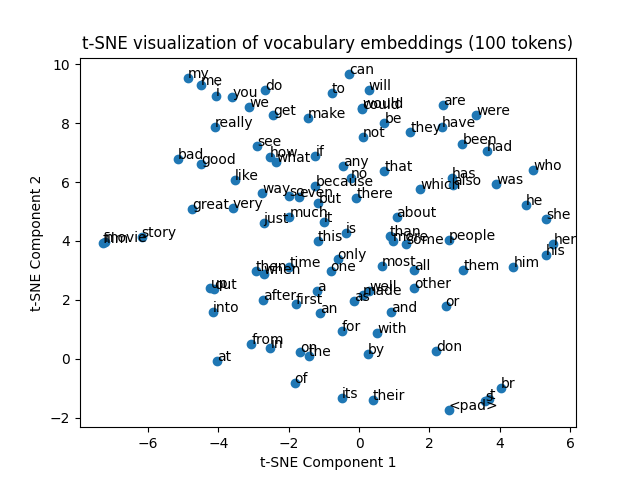

In [5]:
# Plot embeddings of first 100 words using t-SNE
nextplot()
_ = tsne_vocab(glove_embeddings, torch.arange(100), vocab)

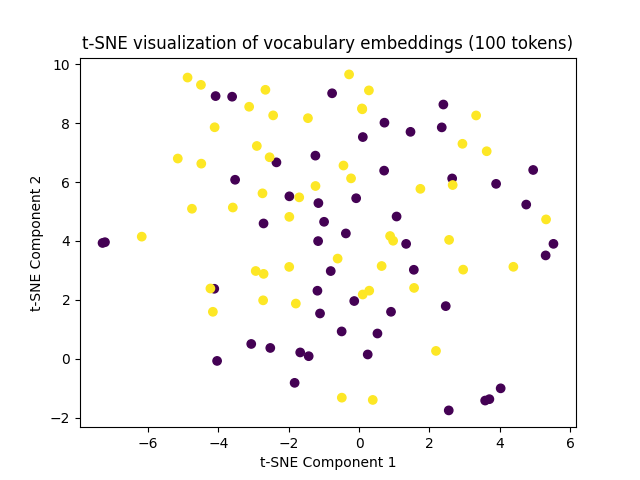

In [6]:
# You can also specify colors and/or drop the item labels
nextplot()
_ = tsne_vocab(glove_embeddings, torch.arange(100), colors=[0] * 50 + [1] * 50)

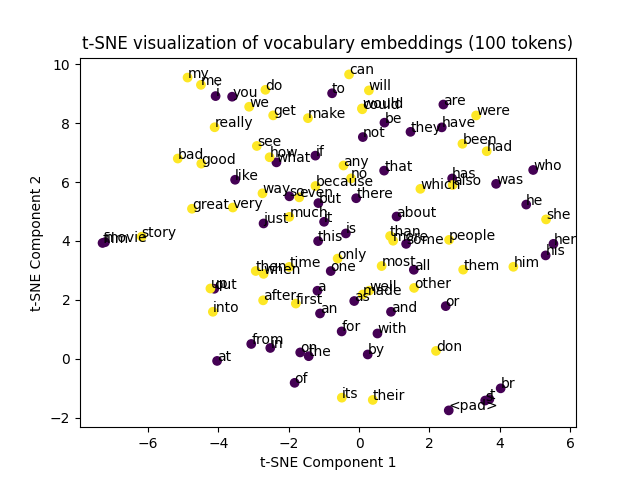

In [7]:
# YOUR CODE HERE
# Note: you can obtain the embeddings tensor using glove_embeddings.weight.data
import torch.nn.functional as F

# Get the actual first 100 words from vocab
n = 100
words_n = [vocab.lookup_token(i) for i in range(n)]
indices_n = torch.arange(n, device=DEVICE)
selected = glove_embeddings.weight[indices_n]

# (i) t-SNE of first 100 words
nextplot()
_ = tsne_vocab(glove_embeddings, indices_n, vocab, colors=[0] * 50 + [1] * 50)

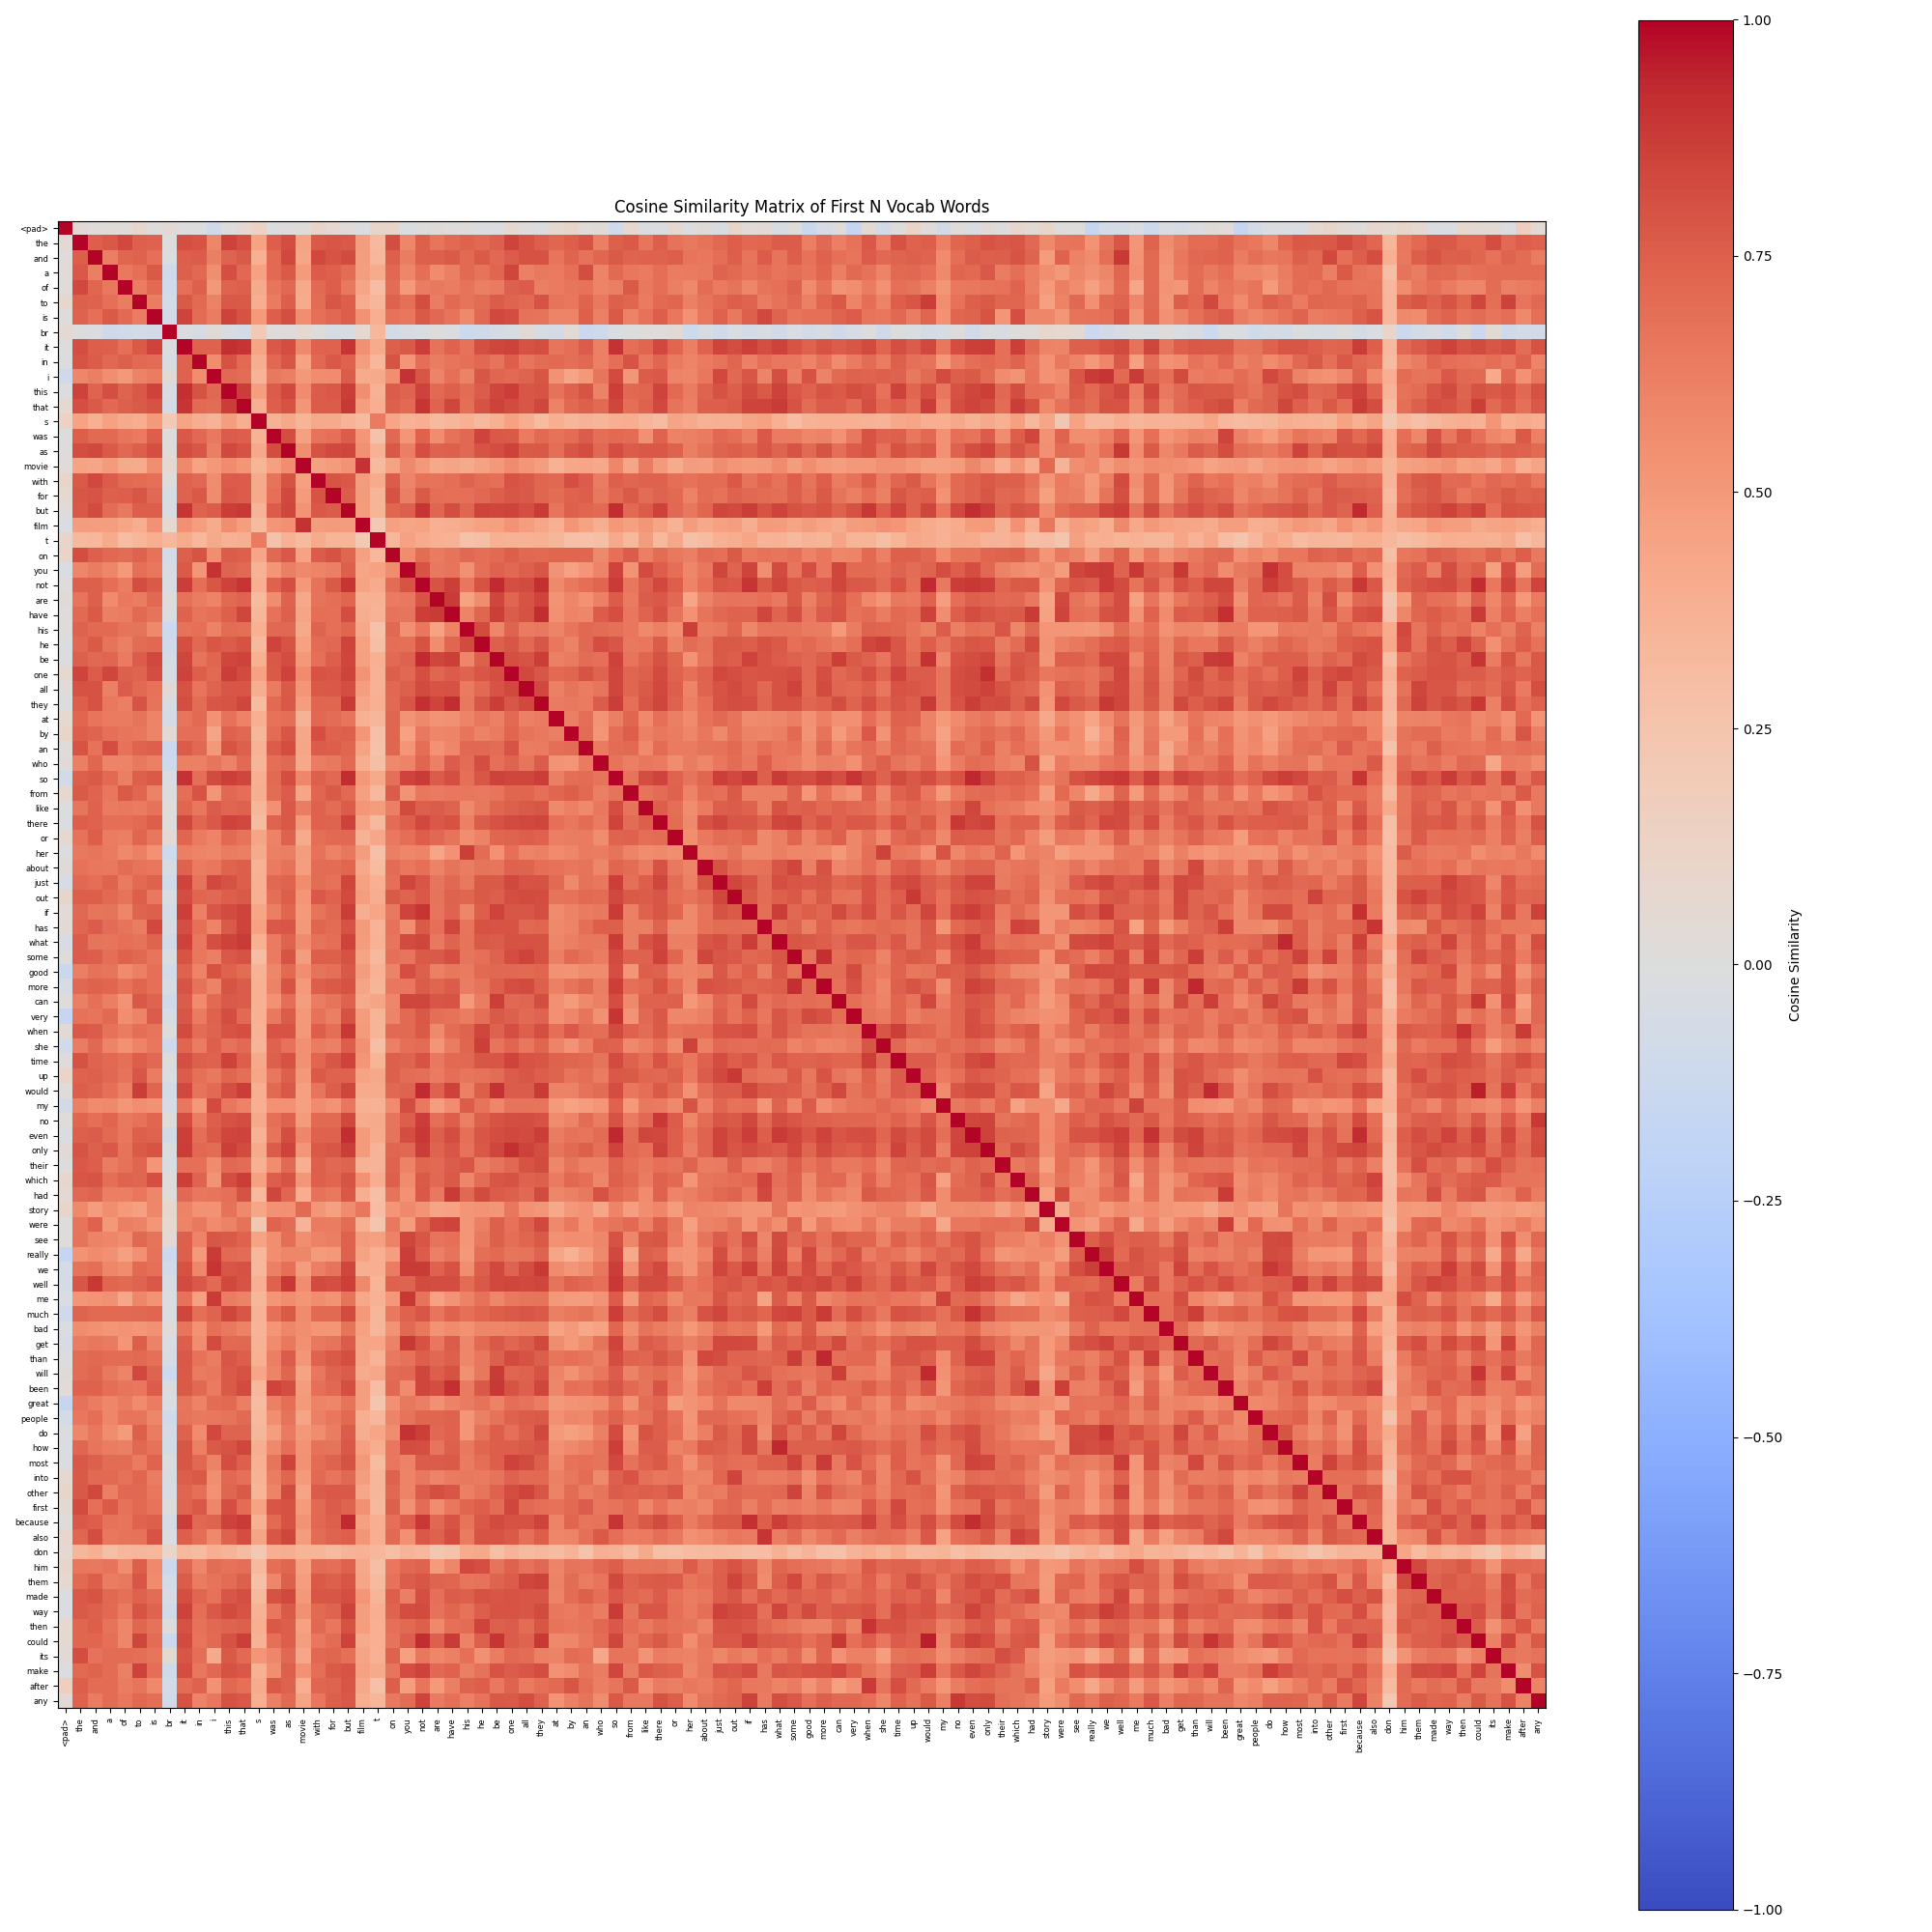

In [8]:
# (ii) Cosine similarity heatmap for first 100 words
sim_matrix = F.cosine_similarity(selected.unsqueeze(1), selected.unsqueeze(0), dim=2)
plt.figure(figsize=(20, 20))
plt.imshow(sim_matrix.detach().cpu().numpy(), cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(100), words_n, rotation=90, fontsize=6)
plt.yticks(range(100), words_n, fontsize=6)
plt.colorbar(label="Cosine Similarity")
plt.title("Cosine Similarity Matrix of First N Vocab Words")
plt.tight_layout()

### Task 5c

In [9]:
# hyperparameter settings for rest of task 5
vocab_size = len(dataset.vocab)
embedding_dim = 100
hidden_dim = 100
num_layers = 2
n_epochs = 10
cell_dropout = 0.0

In [10]:
model = LitSimpleLSTM(vocab_size, embedding_dim, hidden_dim, num_layers, cell_dropout)
dataset = ReviewsDataset(use_vocab=True)
dm = ReviewsDataModule(dataset)
# TODO: Your code here
# Train a plain model so that it reaches a train accuracy of >0.9.
trainer = Trainer(max_epochs=10, check_val_every_n_epoch=1, logger=TensorBoardLogger("tb_logs", name="a03-rnn"))
trainer.fit(model, datamodule=dm)

trainer.test(model, datamodule=dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | SimpleLSTM | 3.4 M  | train | 0    
-----------------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
13.592    Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6775000095367432
        test_loss            1.309981107711792
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 1.309981107711792, 'test_acc': 0.6775000095367432}]

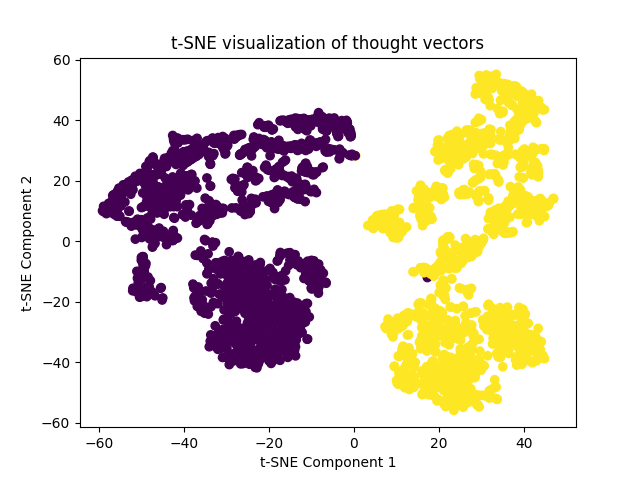

In [11]:
# Plot t-SNE embeddings of the thought vectors for training data
# point color = label
dm.setup("fit")
train_loader = dm.train_dataloader()
nextplot()
_ = tsne_thought(model, train_loader, DEVICE)

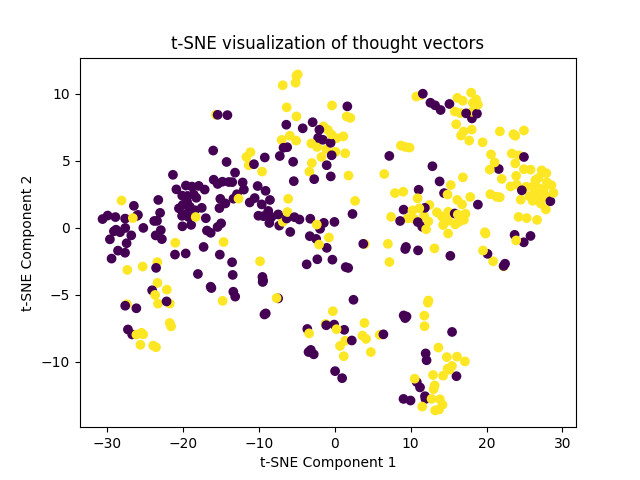

In [12]:
# Plot t-SNE embeddings of of the thought vectors for validation data
dm.setup("fit")
val_loader = dm.val_dataloader()
nextplot()
_ = tsne_thought(model, val_loader, DEVICE)

### Task 5d

Initializing embedding layer with pretrained word embeddings...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | SimpleLSTM | 3.4 M  | train | 0    
-----------------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
13.592    Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Initialized 29841/32363 word embeddings


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7400000095367432
        test_loss           1.1033910512924194
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


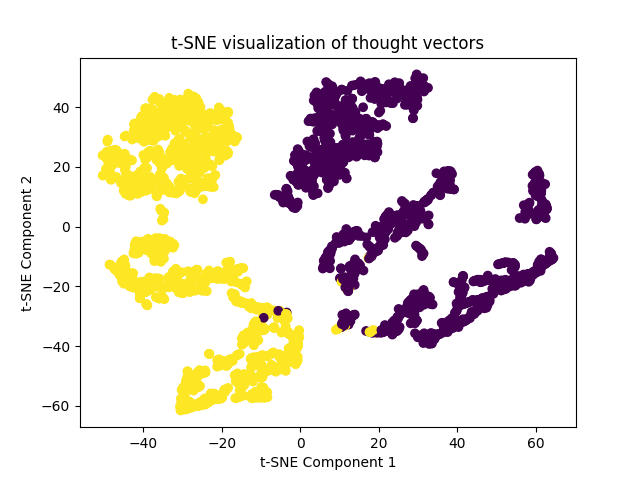

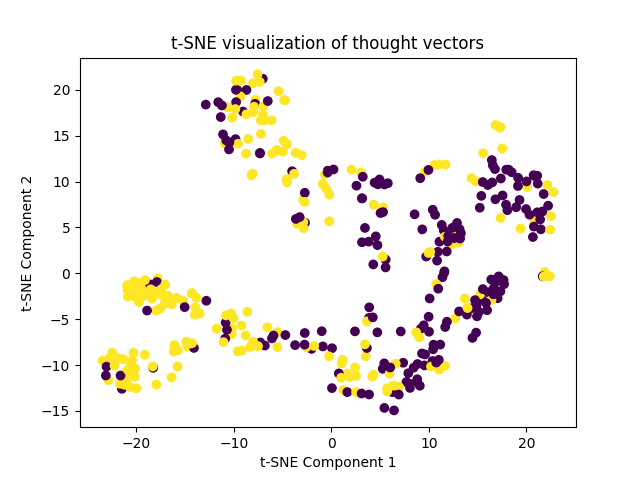

In [13]:
# Initialize the model with *p*re-trained embeddings with *f*inetuning, then
# train.
model_pf = LitSimpleLSTM(
    vocab_size, embedding_dim, hidden_dim, num_layers, cell_dropout
)
reviews_load_embeddings(model_pf.model.embedding, vocab.get_stoi())
# TODO: Your code here

# Train with GloVe-initialized embeddings
trainer_pf = Trainer(max_epochs=10, gradient_clip_val=3, check_val_every_n_epoch=1, logger=TensorBoardLogger("tb_logs", name="a03-rnn-glove"))
trainer_pf.fit(model_pf, datamodule=dm)

trainer_pf.test(model_pf, datamodule=dm)

# (i) Training set thought vectors
dm.setup("fit")
train_loader = dm.train_dataloader()
nextplot()
_ = tsne_thought(model_pf, train_loader, DEVICE)

# (ii) Validation set thought vectors
val_loader = dm.val_dataloader()
nextplot()
_ = tsne_thought(model_pf, val_loader, DEVICE)

### Task 5e

Initializing embedding layer with pretrained word embeddings...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | SimpleLSTM | 3.4 M  | train | 0    
-----------------------------------------------------
161 K     Trainable params
3.2 M     Non-trainable params
3.4 M     Total params
13.592    Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Initialized 29841/32363 word embeddings


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.5099999904632568
        test_loss           0.7394504547119141
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


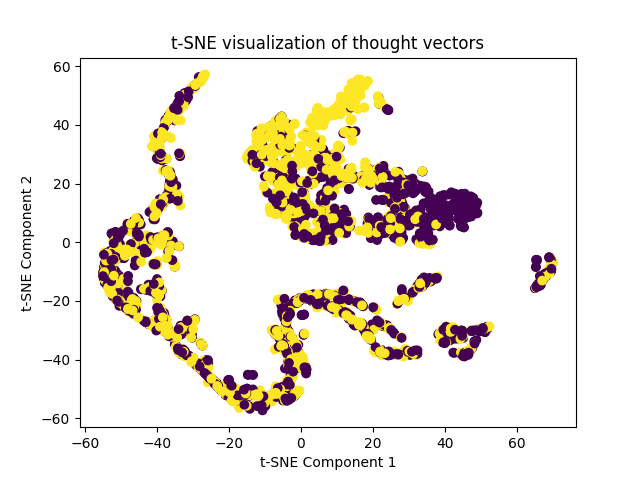

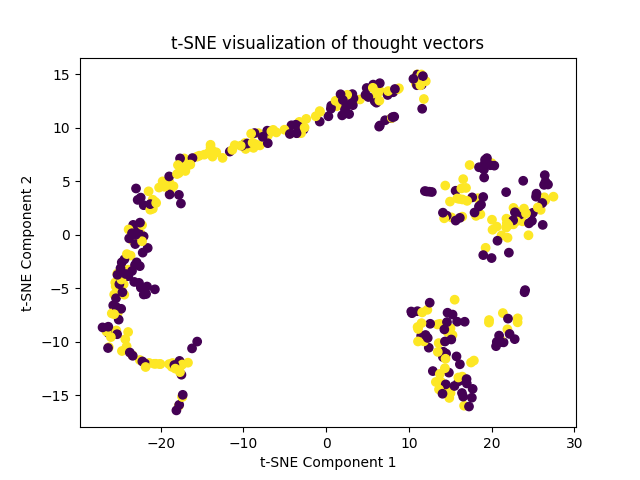

In [14]:
# Initialize the model with *p*re-trained embeddings without finetuning, then
# train.
model_p = LitSimpleLSTM(vocab_size, embedding_dim, hidden_dim, num_layers, cell_dropout)
reviews_load_embeddings(model_p.model.embedding, vocab.get_stoi())
model_p.model.embedding.weight.requires_grad = False
# TODO: Your code here

trainer_p = Trainer(max_epochs=10, gradient_clip_val=3, check_val_every_n_epoch=1, logger=TensorBoardLogger("tb_logs", name="a03-rnn-glove"))
trainer_p.fit(model_p, datamodule=dm)

trainer_p.test(model_p, datamodule=dm)

# (i) Training set thought vectors
dm.setup("fit")
train_loader = dm.train_dataloader()
nextplot()
_ = tsne_thought(model_p, train_loader, DEVICE)

# (ii) Validation set thought vectors
val_loader = dm.val_dataloader()
nextplot()
_ = tsne_thought(model_p, val_loader, DEVICE)

# 5f)

In [15]:
from lightning.pytorch import Trainer
from lightning.pytorch.tuner import Tuner

datamodule = ReviewsDataModule(dataset)
datamodule.setup("fit")

# Find optimal learning rate
model_tuning = LitSimpleLSTM(vocab_size, embedding_dim, hidden_dim, num_layers, cell_dropout)
datamodule = ReviewsDataModule(dataset)
datamodule.setup("fit")

trainer = Trainer(max_epochs=10)
tuner = Tuner(trainer)

# Automatically finds the best lr
lr_finder = tuner.lr_find(model_tuning, datamodule=datamodule)
best_lr = lr_finder.suggestion()
print(f"Best lr: {best_lr}")

# Train with the best lr
model_tuning.lr = best_lr
trainer = Trainer(max_epochs=10)
trainer.fit(model_tuning, datamodule=datamodule)
trainer.test(model_tuning, datamodule=datamodule)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`weights_only` was not set, defaulting to `False`.
/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /home/tu2/projects/IE678-Deep-Learning/a03-rnn/python/.lr_find_9d4ab98e-0584-458a-a211-cbe64fbf5370.ckpt
Restored all states from the checkpoint at /home/tu2/projects/IE678-Deep-Learning/a03-rnn/python/.lr_find_9d4ab98e-0584-458a-a211-cbe64fbf5370.ckpt
Learning rate set to 0.008317637711026709
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------

Best lr: 0.008317637711026709


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
/home/tu2/anaconda3/envs/dl-2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7425000071525574
        test_loss           0.9292088150978088
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.9292088150978088, 'test_acc': 0.7425000071525574}]

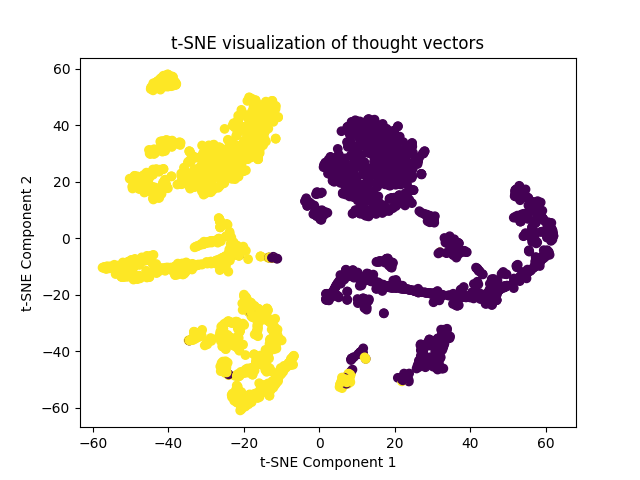

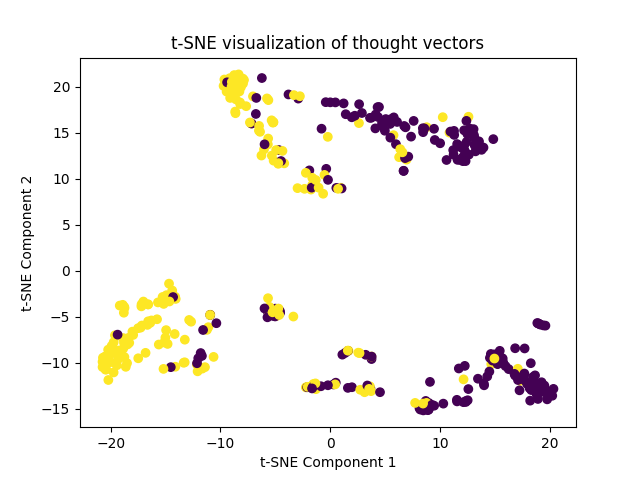

In [16]:
# (i) Training set thought vectors
dm.setup("fit")
train_loader = dm.train_dataloader()
nextplot()
_ = tsne_thought(model_tuning, train_loader, DEVICE)

# (ii) Validation set thought vectors
val_loader = dm.val_dataloader()
nextplot()
_ = tsne_thought(model_tuning, val_loader, DEVICE)